# TI-DeepONet in Neuromancer: DeepONets integrated with numerical time schemes

Recreating TI-DeepONet Heat equation notebook example in Neruomancer from (https://github.com/Centrum-IntelliPhysics/PDEControl_DPC/tree/main)

<!-- <img src="https://github.com/Centrum-IntelliPhysics/PDEControl_DPC/blob/main/DPC_NO.png" width="700"> -->
<img src="https://arxiv.org/html/2505.17341v2/x2.png?raw=true" width="700">

## Time-integrated Deep Operator Network (TI-DeepONet)

**Scope.** In this notebook, we only focus on the **operator learning** part from [[2]](https://arxiv.org/abs/2511.08992). The framework, referred to as TI-DON (Time-integrated Deep Operator Network), is designed to parametrize both state and control outputs to solve the system dynamics efficiently. Here, we

- Learn a differentiable surrogate model of the PDE dynamics
- Predict temporal derivatives and integrate using numerical schemes (Euler/RK4)
- Preserve temporal causality while minimizing error accumulation

### References

[1] [Nayak, D., & Goswami, S. (2025). TI-DeepONet: Learnable Time Integration for Stable Long-Term Extrapolation. arXiv preprint arXiv:2505.17341.](https://arxiv.org/abs/2505.17341)

[2] [Sarkar, D. R., Drgoňa, J., & Goswami, S. (2025). Learning to Control PDEs with Differentiable Predictive Control and Time-Integrated Neural Operators. arXiv preprint arXiv:2511.08992.](https://arxiv.org/abs/2511.08992)


## Problem Setup

### 1. TI-DON Parametrisation
* **State Dynamics ($\mathcal{G}_\theta$):** We train a neural operator $\mathcal{G}_\theta$ to learn the instantaneous time derivative:
    $$
    \mathcal{G}_\theta : (u(t), f(t)) \mapsto \partial_t u
    $$
    This learned operator is integrated using **RK4** (Runge-Kutta 4) for time evolution.
    
* **Control Representation ($f$):** Control inputs are parametrized via **Gaussian basis functions**:
    $$
    f(x, t) = \sum_{i=1}^{n} f_i(t) \cdot \exp \left( - \frac{(x - \mu_i)^2}{2\sigma^2} \right)
    $$
    * **Actuators:** $n=4$ actuators at $\mu_i \in \{0.2, 0.4, 0.6, 0.8\}$ with spread $\sigma = 0.1$.
    * **Amplitudes:** $f_i(t)$ are learned time-varying amplitudes bounded by $|f_i(t)| \le 40$.

### 2. Physical System: Heat Equation
The underlying dynamics follow the Heat Equation with homogeneous Dirichlet boundary conditions:
$$
\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2} + f(x, t), \quad x \in [0, 1], ~ t \in [0, 0.4]
$$
where $\alpha = 0.1$ is the thermal diffusivity.


### Imports

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn


In [2]:
# Set default dtype to float32
torch.set_default_dtype(torch.float)
# PyTorch random seed
seed = 1234
torch.manual_seed(seed)
# NumPy random seed
np.random.seed(seed)

# Device configuration
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


## Dataset

### Data Generation
* **Method:** Finite Difference Method (FDM) with the unconditionally stable **Crank-Nicolson scheme**.
* **Dataset:** 3000 samples with initial conditions from a Gaussian Random Field (GRF).
* **Resolution:** Spatial $\Delta x = 10^{-2}$, Temporal $\Delta t = 10^{-3}$.

The training and testing datasets for all heat equation PDE systems is available at this [link](https://livejohnshopkins-my.sharepoint.com/:f:/g/personal/droysar1_jh_edu/ElrQ5bd7MKRLv5bfn3_Rg9gBBbJHXQHOztZ37scwJGjbqQ?e=aOTLQC). 

Download `heat_smooth_f_dataset.npz`


In [ ]:
data_path = "pathto/datasets/heat_smooth_f_dataset.npz"

In [4]:
dataset = np.load(data_path)  # total 3000 samples available
samples_to_load = 100

solutions = torch.from_numpy(
    dataset["solutions"][:samples_to_load]
)  # shape: (samples, T+1, N)
controls = torch.from_numpy(
    dataset["controls"][:samples_to_load]
)  # shape: (samples, T, 2)
x_cord = torch.from_numpy(dataset["x"]).reshape(-1, 1)  # shape: (N, 1)
dt = dataset["dt"]  # likely a scalar numpy value

print(f"Loaded {samples_to_load}/{dataset['solutions'].shape[0]} samples:")
print("solutions:", solutions.shape)
print("controls:", controls.shape)
print("x:", x_cord.shape)
print("dt:", dt)

Loaded 100/3000 samples:
solutions: torch.Size([100, 401, 100])
controls: torch.Size([100, 400, 4])
x: torch.Size([100, 1])
dt: 0.001


In [5]:
# Slice u_t and u_{t+1}
u_t = solutions[:, :-1, :]  # (samples, T, N)
u_next = solutions[:, 1:, :]  # (samples, T, N)
f_t = controls[:, :, :]  # (samples, T, 2)

print("u_t: ", str(u_t.shape))
print("u_next: ", str(u_next.shape))
print("f_t: ", str(f_t.shape))


u_t:  torch.Size([100, 400, 100])
u_next:  torch.Size([100, 400, 100])
f_t:  torch.Size([100, 400, 4])


### **TI-DeepONet Architecture**

The TI-DeepONet is modified to handle control problems by splitting the "Branch" network into two separate parts.

**1. The Branches (Input Encoders)**
Instead of a single input branch, there are two specialized branches that are multiplied together:
* **State Branch ($b^u$):** Encodes the current state of the system, $u$ (the solution field).
* **Control Branch ($b^a$):** Encodes the external control input, $a$ (the control function).

These two outputs are combined using **element-wise multiplication** ($b^u \odot b^a$) to capture how the state and control interact.

**2. The Trunk (Coordinate Encoder)**
* **Trunk Network ($t$):** This part remains standard. It takes the spatial coordinates (query locations $\zeta$) as input and outputs features based on the grid location.

**3. The Final Output**
The network predicts the **time derivative** ($\partial u / \partial t$) rather than the future state directly. It does this by taking the dot product of the combined branches and the trunk:

$$
\frac{\partial u}{\partial t} \approx \sum_{j=1}^{p} \left[ b_j^u(u^i) \odot b_j^a(a^i) \right] t_j(\zeta)
$$

In [6]:
# flatten (samples × time)
branch_x1 = u_t.reshape(-1, u_t.shape[-1])  # (N, 100)
branch_x2 = f_t.reshape(-1, f_t.shape[-1])  # (N, 4)
outputs = u_next.reshape(-1, u_next.shape[-1])  # (N, 100)

print("branch_x1: ", str(branch_x1.shape))
print("branch_x2: ", str(branch_x2.shape))
print("outputs: ", str(outputs.shape))

branch_x1:  torch.Size([40000, 100])
branch_x2:  torch.Size([40000, 4])
outputs:  torch.Size([40000, 100])


Shuffling enables learning a representation of the gradient $\frac{\partial u}{\partial t}$, and not a sequence mapping a time-step to another time-step

In [7]:
# Shuffle indices (do this on CPU for convenience)
num_samples = branch_x1.shape[0]
g = torch.Generator().manual_seed(seed)
idx = torch.randperm(num_samples)

print("Shuffled indices: ", str(idx))

branch_x1 = branch_x1[idx]
branch_x2 = branch_x2[idx]
outputs = outputs[idx]

Shuffled indices:  tensor([ 9775, 22609, 30410,  ...,  5137,  5332,  9722])


In [8]:
# split
train_frac = 0.8  # percentage
n_train = int(train_frac * num_samples)

print("Number of training samples: ", n_train)

Number of training samples:  32000


### Create named dictionary datasets for NeuroMANCER

In [9]:
from neuromancer.dataset import DictDataset

trunk_grid = torch.as_tensor(x_cord, dtype=torch.float32).reshape(-1, 1)


def build_dictdataset(b1, b2, y, name):
    trunk_inputs = trunk_grid.expand(b1.shape[0], -1, -1)  # (N, 100, 1)
    return DictDataset(
        {
            "u_t": b1.float(),  # (N, 100)
            "f_t": b2.float(),  # (N, 4)
            "trunk_inputs": trunk_inputs.float(),  # (N, 100, 1)
            "outputs": y.float(),  # (N, 100)
        },
        name=name,
    )


train_ds = build_dictdataset(
    branch_x1[:n_train], branch_x2[:n_train], outputs[:n_train], "train"
)
test_ds = build_dictdataset(
    branch_x1[n_train:], branch_x2[n_train:], outputs[n_train:], "test"
)


In [10]:
# check dimensions
print("Dimensions check train:")
print(
    "branch_inputs_1 -> u_t:", train_ds.datadict["u_t"].shape
)  # (N, 100) spatial field
print("branch_inputs_2 -> f_t :", train_ds.datadict["f_t"].shape)  # (N, 4) actuators
print(
    "trunk_inputs -> x_coord:", train_ds.datadict["trunk_inputs"].shape
)  # (N, 100, 1) grid., broadcasted N times
print("outputs- > u_t+1:", train_ds.datadict["outputs"].shape)  # (N, 100) output field

print("Dimensions check test:")
print(
    "branch_inputs_1 -> u_t:", test_ds.datadict["u_t"].shape
)  # (N, 100) spatial field
print("branch_inputs_2 - f_t :", test_ds.datadict["f_t"].shape)  # (N, 4) actuators
print(
    "trunk_inputs-> x_coord:", test_ds.datadict["trunk_inputs"].shape
)  # (N, 100, 1) grid., broadcasted N times
print("outputs -> u_t+1:", test_ds.datadict["outputs"].shape)  # (N, 100) output field

Dimensions check train:
branch_inputs_1 -> u_t: torch.Size([32000, 100])
branch_inputs_2 -> f_t : torch.Size([32000, 4])
trunk_inputs -> x_coord: torch.Size([32000, 100, 1])
outputs- > u_t+1: torch.Size([32000, 100])
Dimensions check test:
branch_inputs_1 -> u_t: torch.Size([8000, 100])
branch_inputs_2 - f_t : torch.Size([8000, 4])
trunk_inputs-> x_coord: torch.Size([8000, 100, 1])
outputs -> u_t+1: torch.Size([8000, 100])


### Create torch DataLoaders for the Trainer

In [11]:
batch_size = 25
print(f"batch_size: {batch_size}")

# Do this on device, as it needs to for Training
g_device = torch.Generator(device=device).manual_seed(seed)

batch_size: 25


Randomly sample from training data set 1000 times per epoch, with `replacement=True`. This means there's a chance to pick up the same data again. This fully random sampling allows efficient learning of the representation of the gradient.

In [12]:
steps_per_epoch = 1000
num_samples = steps_per_epoch * batch_size

sampler = torch.utils.data.RandomSampler(
    train_ds,
    replacement=True,
    num_samples=num_samples,
    generator=g_device,
)

train_loader = torch.utils.data.DataLoader(
    train_ds,
    batch_size=batch_size,
    sampler=sampler,
    collate_fn=train_ds.collate_fn,
    drop_last=True,
    shuffle=False,  # must be False when sampler is provided
)

In [13]:
# Only shuffle the training set
test_loader = torch.utils.data.DataLoader(
    test_ds,
    batch_size=batch_size,
    collate_fn=test_ds.collate_fn,
    shuffle=False,
)

## Exporting DeepONet from DeepXDE in Neuromancer

We use the DeepONets available in the `dde.nn` library within Neuromancer. Here, we use `dde.nn.MIONetCartesianProd` with the PyTorch backend `os.environ["DDE_BACKEND"] = "pytorch"`. This architecture allows the usage of two input branches along with a trunk. 

Code: (https://deepxde.readthedocs.io/en/latest/_modules/deepxde/nn/pytorch/mionet.html#MIONetCartesianProd)


In [14]:
os.environ["DDE_BACKEND"] = "pytorch"
import deepxde as dde

activation = {
    "branch1": "gelu",
    "branch2": "gelu",
    "trunk": "tanh",
}

hidden_dim = 100

layer_sizes_branch1 = [100, 128, 128, 128, hidden_dim]  # u_t: (B,100) -> (B,100)
layer_sizes_branch2 = [4, 32, 32, 32, hidden_dim]  # f_t: (B,4)   -> (B,100)
layer_sizes_trunk = [1, 64, 64, 64, hidden_dim]  # x:   (100,1) -> (100,100

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [15]:
net = dde.nn.MIONetCartesianProd(
    layer_sizes_branch1=layer_sizes_branch1,
    layer_sizes_branch2=layer_sizes_branch2,
    layer_sizes_trunk=layer_sizes_trunk,
    activation=activation,
    kernel_initializer="Glorot normal",  # weight initialisation available in DeepXDE
    trunk_last_activation=True,  # matches the JAX trunk applying tanh after every Dense
    merge_operation="mul",  # y_func = y_func1 * y_func2
    layer_sizes_merger=None,  # no extra merger MLP
    layer_sizes_output_merger=None,  # keep dot-product einsum
)

A wrapper is needed for the DictDataset format to work with DeepXDE models.
`DeepXDEWrapper` makes DeepXDE models compatible with NeuroMANCER Nodes and supports one or two branches. It fixes the `trunk_input` broadcast.

In [16]:
from neuromancer.modules.operators import DeepXDEWrapper

deeponet_wrapped = DeepXDEWrapper(
    model=net,
    is_cartesian=True,
    branch_keys=["u_t", "f_t"],
)
# print(deeponet_wrapped)

### neuromancer.dynamics.integrators compatibility for DeepONet

We need to bind the DeepONet with a fixed trunk tensor and expose `in_features`/`out_features` derived from the trunk `m` dimension. This is required for `neuromancer.dynamics.integrators` compatibility. The `DeepXDEIntegratorWrapper` wrapper deals with this.

- `u_t` (state): `(B, 100)`
- `f_t` (control): `(B, 4)`
- `trunk_grid`: `(100, 1)` (fixed spatial grid)
- `du/dt` prediction: `(B, 100)`
- `deeponet_integrator.in_features = deeponet_integrator.out_features = 100`

In [17]:
from neuromancer.modules.operators import DeepXDEIntegratorWrapper

deeponet_integrator = DeepXDEIntegratorWrapper(
    model=deeponet_wrapped,
    trunk_inputs=trunk_grid,
)

In [18]:
# print(deeponet_integrator)

### Time integrator in the system

In [19]:
from neuromancer.dynamics import integrators

fxRK4 = integrators.DiffEqIntegrator(deeponet_integrator, h=dt, method="rk4")

In [20]:
from neuromancer.system import Node

node_rk4 = Node(
    fxRK4,
    ["u_t", "f_t"],
    ["u_t"],
    name="TI_DON + RK4",
)

## Objective and Constraints in NeuroMANCER

**Loss Function.** We utilize a fully data-driven approach using Mean Squared Error (MSE). The loss is calculated by comparing the ground truth data $u_{t+1}$ against the predicted state $\hat{u}_{t+1}$, which is obtained by integrating the DeepONet output through an RK4 step:

$$
\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} \left( \hat{u}_{t+1}^{(i)} - u_{t+1}^{(i)} \right)^2
$$

In [21]:
from neuromancer.problem import Problem
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.constraint import Objective

var_y_est = variable("u_t")
var_y_true = variable("outputs")

# MSE: mean((u_next - outputs)^2)
mse_var = (var_y_est - var_y_true) ** 2
mse_obj = Objective(mse_var, metric=torch.mean, name="mse_loss")

loss = PenaltyLoss(objectives=[mse_obj], constraints=[])


## Problem Solution in NeuroMANCER

In [22]:
# Use RK4 node
problem = Problem(
    nodes=[node_rk4],
    loss=loss,
    #   grad_inference=True
)


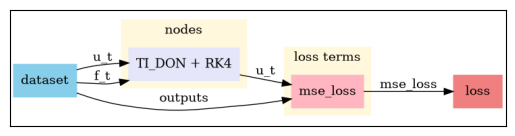

In [23]:
problem.show()  # graphviz library needed for graph visualization

## Training the TI-DON

In [24]:
# result_dir = './'
epochs = int(10)  # 10 passes of 1000 steps each
log_every = 100
lr = 1e-3
transition_steps = 2000
decay_rate = 0.9

The learning rate is updated at each optimizer step using an exponential decay schedule,
$$
\eta_k = \eta_0 \, \gamma^{\,k / T},
$$
where $\eta_0$ is the base learning rate (`lr`), $ \gamma \in (0,1) $ is the decay rate (`decay_rate`), $ k $ denotes the optimizer step index, and $ T $ is the transition scale (`transition_steps`) controlling the decay speed.


In [25]:
from torch.optim.lr_scheduler import LambdaLR
from neuromancer.callbacks import Callback

optimizer = torch.optim.Adam(problem.parameters(), lr=lr)


def exponential_decay(step: int) -> float:
    """Exponential learning-rate decay applied per optimizer step."""
    return decay_rate ** (step / transition_steps)


scheduler = LambdaLR(optimizer, lr_lambda=exponential_decay)

The custom callback `StepLRSchedulerCallback` updates the learning rate at every training step (batch) and optionally logs the training loss at a fixed step interval.

It gives the printed format:
`epoch: <epoch> step: <step_in_epoch> <loss_name>: <loss_value>`

In [ ]:
class StepLRSchedulerCallback(Callback):
    """
    Scheduler that steps every batch end, and logs loss every `log_every`.

    Args:
        scheduler: Learning rate scheduler to step.
        log_every: Frequency of logging loss (in number of steps). If 0, no logging.
        global_step: Internal counter for total steps taken.
        epoch_step: Counter for steps within the current epoch.
        step_indices: List of global step indices where loss was logged.
        step_losses: List of losses corresponding to the logged step indices.
    """

    def __init__(self, scheduler, log_every=1):
        super().__init__()
        self.scheduler = scheduler
        self.log_every = log_every
        self.global_step = 0
        self._last_epoch = None
        self.epoch_step = 0
        self.step_indices = []
        self.step_losses = []

    def end_batch(self, trainer, output):
        if self._last_epoch != trainer.current_epoch:
            self._last_epoch = trainer.current_epoch
            self.epoch_step = 0

        self.scheduler.step()

        if self.log_every and self.epoch_step % self.log_every == 0:
            loss = output.get(trainer.train_metric)
            if loss is not None:
                loss_val = loss.detach().cpu().item()
                print(
                    f"epoch: {trainer.current_epoch} step: {self.epoch_step} "
                    f"{trainer.train_metric}: {loss_val:.6g}"
                )
                self.step_indices.append(self.global_step)
                self.step_losses.append(loss_val)

        self.epoch_step += 1
        self.global_step += 1


lr_callback = StepLRSchedulerCallback(scheduler, log_every=100)  # set as needed

### Construct Trainer and solve the problem

In [27]:
from neuromancer.trainer import Trainer

trainer = Trainer(
    problem.to(device),
    train_data=train_loader,
    # dev_data=dev_loader,        # optional
    test_data=test_loader,
    optimizer=optimizer,
    callback=lr_callback,
    epochs=epochs,
    epoch_verbose=1,
    train_metric="train_loss",
    dev_metric="train_loss",  # or "dev_loss" if you use dev_data
    eval_metric="train_loss",
    test_metric="test_loss",
    warmup=epochs,
    device=device,
)

In [28]:
%%time
best_model = trainer.train()

epoch: 0 step: 0 train_loss: 0.000296707
epoch: 0 step: 100 train_loss: 0.000152601
epoch: 0 step: 200 train_loss: 8.52315e-05
epoch: 0 step: 300 train_loss: 5.20423e-05
epoch: 0 step: 400 train_loss: 5.12071e-05
epoch: 0 step: 500 train_loss: 4.34851e-05
epoch: 0 step: 600 train_loss: 2.76061e-05
epoch: 0 step: 700 train_loss: 2.82569e-05
epoch: 0 step: 800 train_loss: 3.76164e-05
epoch: 0 step: 900 train_loss: 2.43377e-05
epoch: 0  train_loss: 5.828392750117928e-05
epoch: 1 step: 0 train_loss: 1.72889e-05
epoch: 1 step: 100 train_loss: 1.30394e-05
epoch: 1 step: 200 train_loss: 1.15833e-05
epoch: 1 step: 300 train_loss: 1.01395e-05
epoch: 1 step: 400 train_loss: 5.67049e-06
epoch: 1 step: 500 train_loss: 1.04461e-05
epoch: 1 step: 600 train_loss: 8.19555e-06
epoch: 1 step: 700 train_loss: 4.04087e-06
epoch: 1 step: 800 train_loss: 5.7684e-06
epoch: 1 step: 900 train_loss: 4.49501e-06
epoch: 1  train_loss: 8.438807526545133e-06
epoch: 2 step: 0 train_loss: 4.44341e-06
epoch: 2 step: 1

In [29]:
# load best trained model
trainer.dev_data = trainer.train_data  # workaround for replacing dev set to match keys
best_outputs = trainer.test(best_model)
problem.load_state_dict(best_model)

<All keys matched successfully>

In [30]:
train_loss_history = [l.detach().cpu().numpy() for l in trainer.loss_history["train"]]
mean_test_loss = best_outputs["mean_test_loss"].detach().cpu().numpy()
print(f"mean_test_loss: {mean_test_loss}")
print(f"len(train_loss_history): {len(train_loss_history)}")


mean_test_loss: 1.559284328322974e-06
len(train_loss_history): 10


## Plot loss history w/ mean test loss

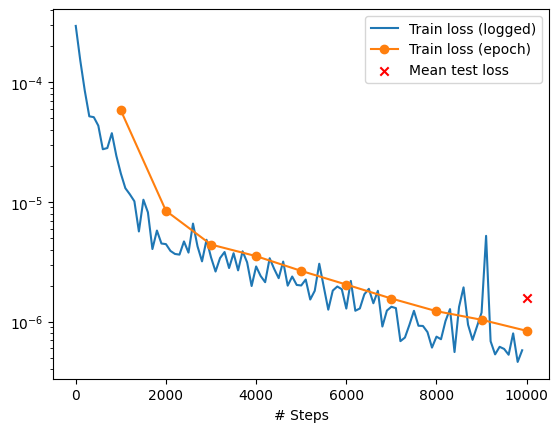

In [31]:
epoch_steps = (np.arange(len(train_loss_history)) + 1) * steps_per_epoch

plt.semilogy(
    lr_callback.step_indices, lr_callback.step_losses, label="Train loss (logged)"
)
plt.semilogy(epoch_steps, train_loss_history, "o-", label="Train loss (epoch)")

plt.scatter(
    epoch_steps[-1],
    mean_test_loss,
    label="Mean test loss",
    c="red",
    marker="x",
)

plt.xlabel("# Steps")
plt.legend()
plt.show()


## Test time predictions

In [32]:
def autoregressive_rollout(sample_id_value):
    node = problem.nodes[0].to(device)
    node.eval()

    with torch.no_grad():
        u_t = solutions[sample_id_value, 0, :].float().to(device)
        true_states = solutions[sample_id_value, :, :].float().to(device)
        control_seq = controls[sample_id_value, :, :].float().to(device)

        preds = [u_t]
        for t in range(control_seq.shape[0]):
            batch = {
                "u_t": u_t.unsqueeze(0),
                "f_t": control_seq[t : t + 1, :],
            }
            out = node(batch)
            u_t = out["u_t"].squeeze(0)
            preds.append(u_t)

        rollout_pred = torch.stack(preds, dim=0)
        mse_loss = torch.mean((true_states - rollout_pred) ** 2)
        rel_l2_error = torch.linalg.norm(
            true_states - rollout_pred
        ) / torch.linalg.norm(true_states)

    return mse_loss, rel_l2_error, rollout_pred, true_states


In [33]:
sample_id = 12  # change this to test other samples
mse_loss, rel_l2_error, rollout_pred, true_states = autoregressive_rollout(sample_id)
print(mse_loss.item(), rel_l2_error.item())

0.016123605892062187 0.1327262818813324


In [34]:
import matplotlib.gridspec as gridspec


def plot_rollout_results(
    true_states,
    rollout_pred,
    x_cord,
    dt_value,
    sample_id_value,
):
    x_axis = x_cord.squeeze()
    T_plus_1 = true_states.shape[0]
    time_axis = np.linspace(0, dt_value * (T_plus_1 - 1), T_plus_1)
    error = np.abs(true_states - rollout_pred)

    vmin = float(min(true_states.min(), rollout_pred.min()))
    vmax = float(max(true_states.max(), rollout_pred.max()))

    fig = plt.figure(figsize=(20, 10))
    gs = gridspec.GridSpec(
        3,
        3,
        height_ratios=[20, 0.3, 1.0],
        width_ratios=[1, 1, 1],
        hspace=0.15,
        wspace=0.2,
        bottom=0.15,
        top=0.88,
        left=0.08,
        right=0.95,
    )

    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)
    ax2 = fig.add_subplot(gs[0, 2], sharey=ax0)

    im0 = ax0.contourf(
        x_axis, time_axis, true_states, levels=120, cmap="inferno", vmin=vmin, vmax=vmax
    )
    ax0.set_title("FDM Prediction", fontsize=22)
    ax0.set_xlabel("x", fontsize=20)
    ax0.set_ylabel("t", fontsize=20)
    ax0.tick_params(labelsize=18)

    im1 = ax1.contourf(
        x_axis,
        time_axis,
        rollout_pred,
        levels=120,
        cmap="inferno",
        vmin=vmin,
        vmax=vmax,
    )
    ax1.set_title("TI DON Prediction", fontsize=22)
    ax1.set_xlabel("x", fontsize=20)
    ax1.tick_params(labelsize=18, labelleft=False)

    im2 = ax2.contourf(x_axis, time_axis, error, levels=120, cmap="magma")
    ax2.set_title("Absolute Error", fontsize=22)
    ax2.set_xlabel("x", fontsize=20)
    ax2.tick_params(labelsize=18, labelleft=False)

    cbar_ax1 = fig.add_subplot(gs[2, 0:2])
    cbar1 = fig.colorbar(im1, cax=cbar_ax1, orientation="horizontal")
    cbar1.set_label("u", fontsize=20)
    cbar1.ax.tick_params(labelsize=18)

    cbar_ax2 = fig.add_subplot(gs[2, 2])
    cbar2 = fig.colorbar(im2, cax=cbar_ax2, orientation="horizontal")
    cbar2.set_label("Abs. Error", fontsize=20)
    cbar2.ax.tick_params(labelsize=18)

    plt.show()


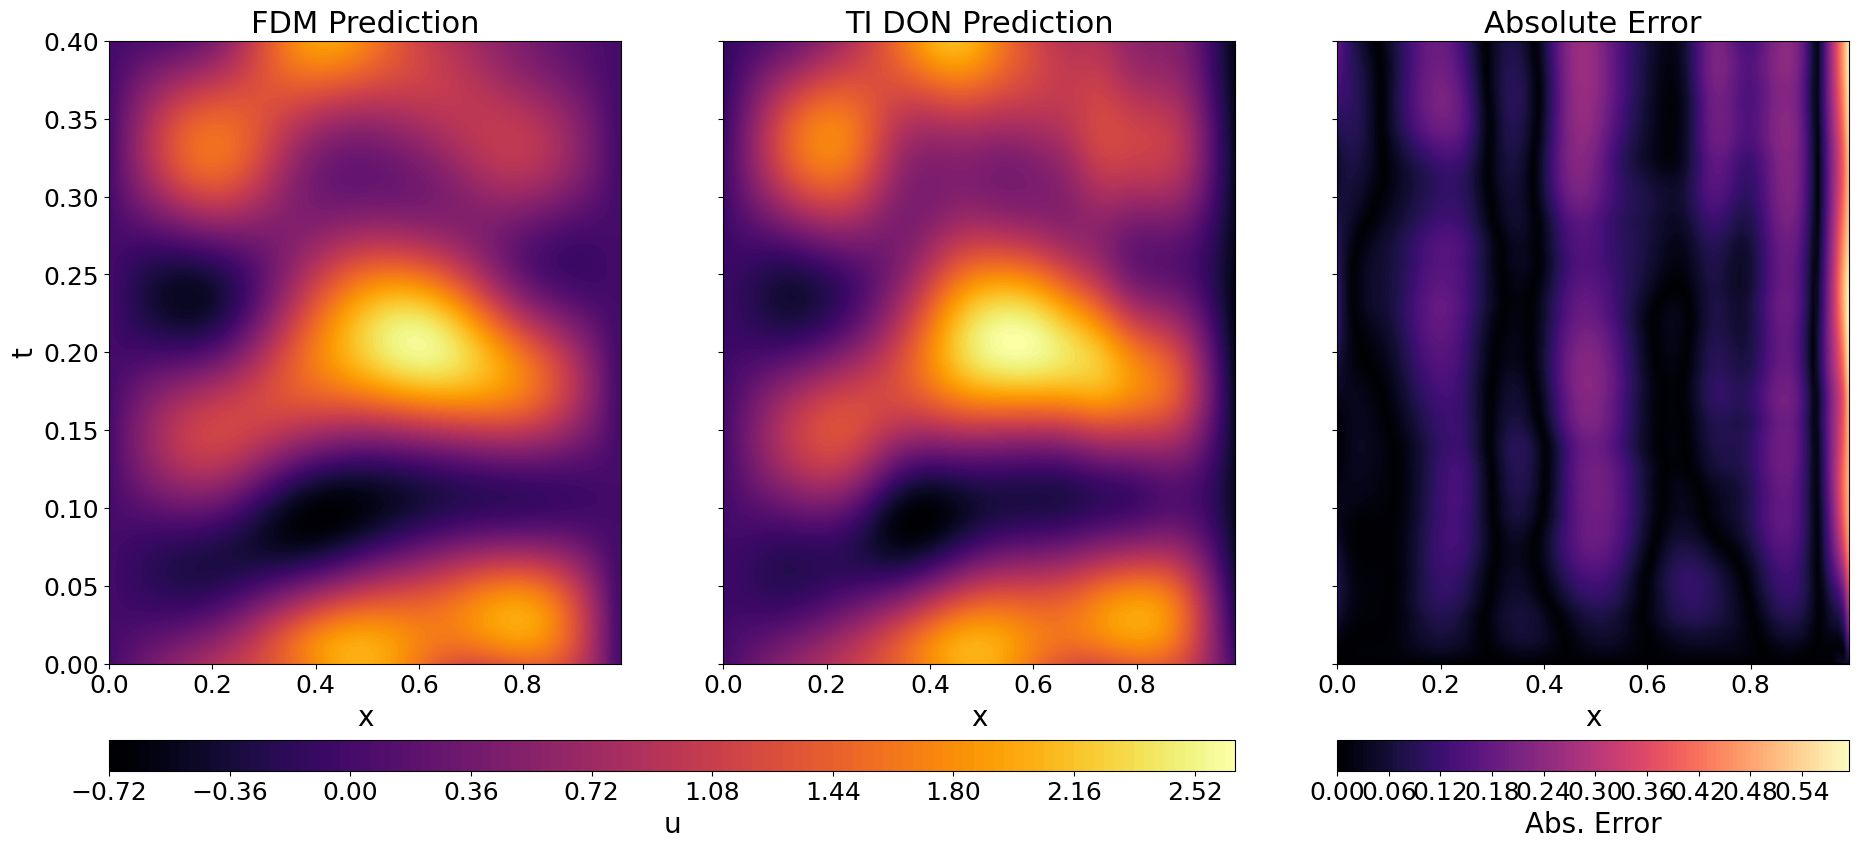

In [35]:
# assumes plot_rollout_results is already defined


def rollout_and_plot(sample_id_value):
    node = problem.nodes[0].to(device)
    node.eval()

    with torch.no_grad():
        u_t = solutions[sample_id_value, 0, :].float().to(device)
        true_states = solutions[sample_id_value, :, :].float().to(device)
        control_seq = controls[sample_id_value, :, :].float().to(device)

        preds = [u_t]
        for t in range(control_seq.shape[0]):
            batch = {
                "u_t": u_t.unsqueeze(0),
                "f_t": control_seq[t : t + 1, :],
            }
            out = node(batch)
            u_t = out["u_t"].squeeze(0)
            preds.append(u_t)

        rollout_pred = torch.stack(preds, dim=0)

    plot_rollout_results(
        true_states.detach().cpu().numpy(),
        rollout_pred.detach().cpu().numpy(),
        x_cord.detach().cpu().numpy(),
        dt,
        sample_id_value,
    )


# run it
rollout_and_plot(sample_id)
